# HATR su dataset interi: River vs CapyMOA

Configurazione `adaptive`, no bootstrap su Bike (17 379 istanze), Fried (40 768) e HyperPlaneRegression (50 000) in prequential evaluation. Metriche: MAE e R² cumulativi.

## Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(
    os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), (
    f'JAR non trovato: {HATR_JAR}\n'
    'compilare: cd implementation/hatr-moa && mvn package -DskipTests')

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel → Restart & Run All')
else:
    os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print('Setup OK')

Setup OK


## Dataset

In [2]:
HYPER_N = 50_000

datasets = {}
datasets['Bike']  = utils.materialize_stream(Bike())
datasets['Fried'] = utils.materialize_stream(Fried())
datasets['Hyper'] = utils.materialize_stream(
    HyperPlaneRegression(
        instance_random_seed=1, number_of_attributes=10,
        number_of_drifting_attributes=2, magnitude_of_change=0.001,
        noise_percentage=5),
    max_instances=HYPER_N)

for name, (X, y, _) in datasets.items():
    print(f'{name:<8}  n={len(X):>6}  feat={X.shape[1]:>2}  '
          f'y∈[{y.min():.2f}, {y.max():.2f}]')

Bike      n= 17379  feat=12  y∈[1.00, 977.00]
Fried     n= 40768  feat=10  y∈[-1.23, 30.52]
Hyper     n= 50000  feat=10  y∈[56.28, 677.42]


## Parametri

In [3]:
BASE = dict(
    grace_period            = 200,
    delta                   = 1e-7,
    tau                     = 0.05,
    leaf_prediction         = 'adaptive',
    bootstrap_sampling      = True,
    model_selector_decay    = 0.95,
    drift_window_threshold  = 500,
    switch_significance     = 0.05,
    min_samples_split       = 5,
    adwin_delta             = 0.0001,
    learning_ratio          = 0.01,
    seed                    = 0,
)

CFG   = {'leaf_prediction': BASE['leaf_prediction'], 'bootstrap_sampling': BASE['bootstrap_sampling']}
SCALE = True
SKIP  = 50

print('Parametri configurati:', BASE)

Parametri configurati: {'grace_period': 200, 'delta': 1e-07, 'tau': 0.05, 'leaf_prediction': 'adaptive', 'bootstrap_sampling': True, 'model_selector_decay': 0.95, 'drift_window_threshold': 500, 'switch_significance': 0.05, 'min_samples_split': 5, 'adwin_delta': 0.0001, 'learning_ratio': 0.01, 'seed': 0}


## Esecuzione

In [5]:
# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', CFG, BASE, schema=_w_schema, scale=SCALE)

results = {}

for name, (X, y, schema) in datasets.items():
    print(f'{name} — River ...', end=' ', flush=True)
    rp, _, t_p_r, t_t_r, _ = utils.prequential_eval(X, y, 'river', CFG, BASE, scale=SCALE, time_algo=True)
    print(f'{t_p_r + t_t_r:.1f}s | CapyMOA ...', end=' ', flush=True)
    cp, _, t_p_c, t_t_c, _ = utils.prequential_eval(X, y, 'capy', CFG, BASE, schema=schema, scale=SCALE, time_algo=True)
    print(f'{t_p_c + t_t_c:.1f}s')
    results[name] = {'y': y, 'river': rp, 'capy': cp}

print('\nDone.')

Bike — River ... 1.0s | CapyMOA ... 0.5s
Fried — River ... 3.5s | CapyMOA ... 1.4s
Hyper — River ... 4.3s | CapyMOA ... 1.6s

Done.


## Risultati

In [6]:
rows = []
for name, d in results.items():
    yt, rp, cp = d['y'], d['river'], d['capy']
    for fwk, yp in [('River', rp), ('CapyMOA', cp)]:
        rows.append(dict(
            Dataset   = name,
            Framework = fwk,
            N         = len(yt),
            MAE       = utils.mae(yt[SKIP:], yp[SKIP:]),
            RMSE      = utils.rmse(yt[SKIP:], yp[SKIP:]),
            R2        = utils.r2(yt[SKIP:], yp[SKIP:]),
        ))

df = pd.DataFrame(rows).set_index(['Dataset', 'Framework'])
df['MAE']  = df['MAE'].map('{:.4f}'.format)
df['RMSE'] = df['RMSE'].map('{:.4f}'.format)
df['R2']   = df['R2'].map('{:.4f}'.format)
print(df.to_string())

                       N      MAE      RMSE      R2
Dataset Framework                                  
Bike    River      17379  75.1715  138.7534  0.4152
        CapyMOA    17379  68.9258  114.1605  0.6042
Fried   River      40768   1.9264    2.4835  0.7530
        CapyMOA    40768   1.9701    2.5319  0.7433
Hyper   River      50000   8.6646   16.1792  0.9449
        CapyMOA    50000   9.0754   16.2482  0.9444


## Curve di apprendimento

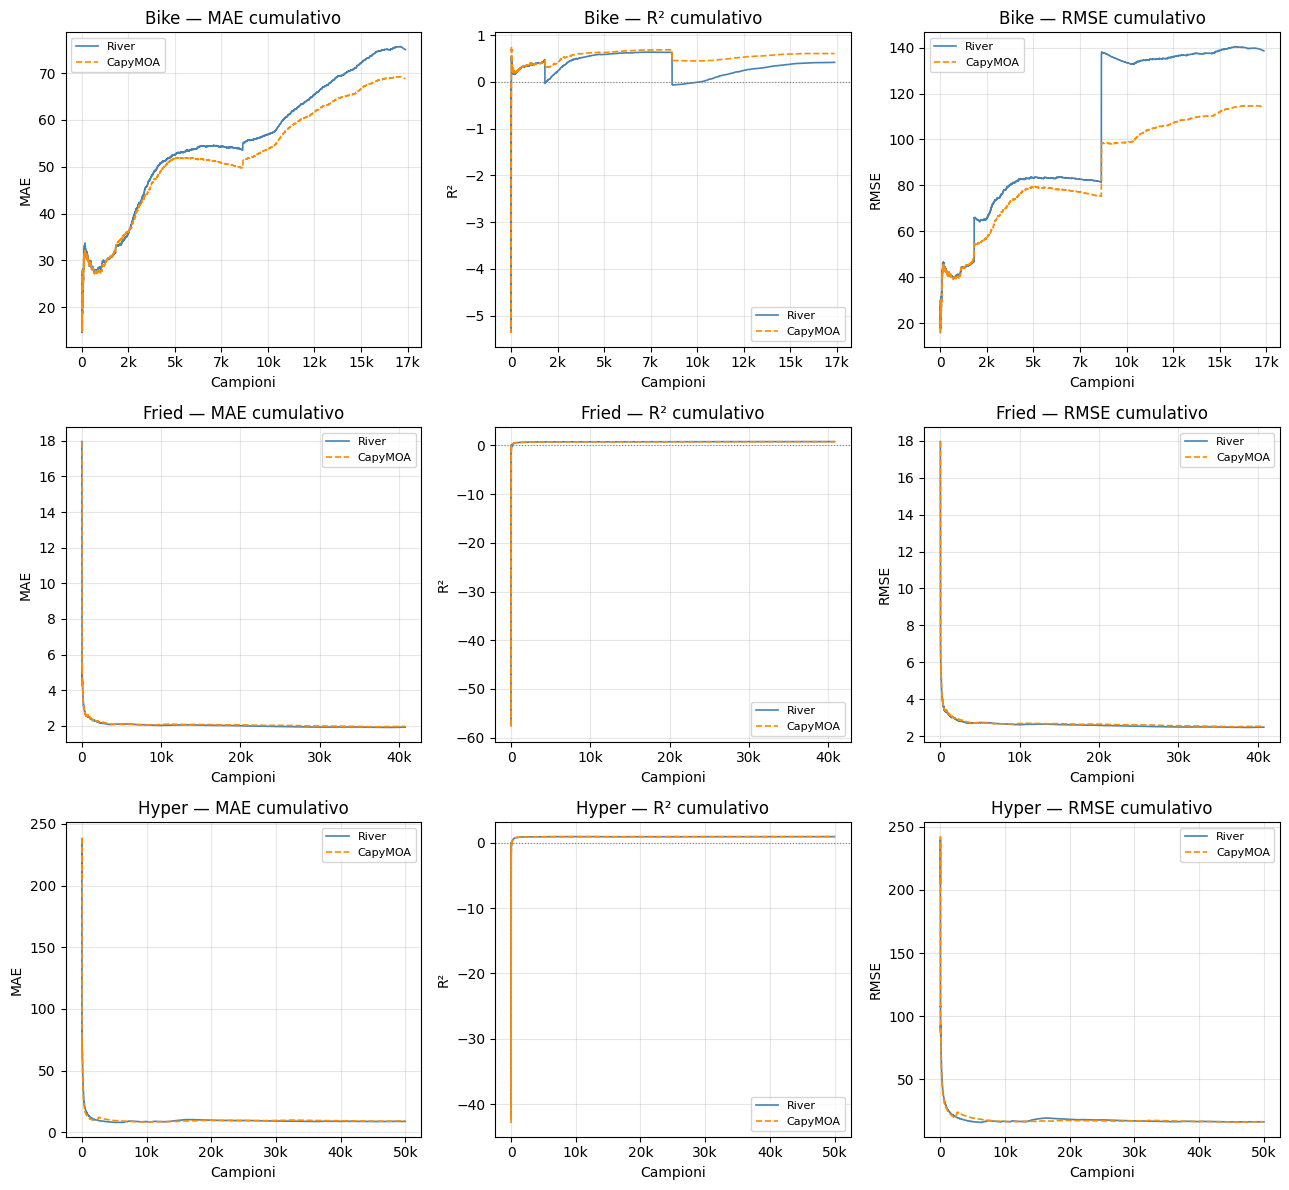

In [7]:
COL_R = 'steelblue'
COL_C = 'darkorange'

fig, axes = plt.subplots(len(results), 3, figsize=(13, 4 * len(results)))
if len(results) == 1:
    axes = axes[np.newaxis, :]

for row_idx, (name, d) in enumerate(results.items()):
    yt, rp, cp = d['y'], d['river'], d['capy']
    n = len(yt)
    xs = np.arange(n)

    ax = axes[row_idx, 0]
    ax.plot(xs, utils.cum_mae(yt, rp), color=COL_R, lw=1.2, label='River')
    ax.plot(xs, utils.cum_mae(yt, cp), color=COL_C, lw=1.2, ls='--', label='CapyMOA')
    ax.set(title=f'{name} — MAE cumulativo', xlabel='Campioni', ylabel='MAE')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{int(v/1000)}k' if v >= 1000 else str(int(v))))

    ax = axes[row_idx, 1]
    ax.plot(xs, utils.cum_r2(yt, rp), color=COL_R, lw=1.2, label='River')
    ax.plot(xs, utils.cum_r2(yt, cp), color=COL_C, lw=1.2, ls='--', label='CapyMOA')
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set(title=f'{name} — R² cumulativo', xlabel='Campioni', ylabel='R²')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{int(v/1000)}k' if v >= 1000 else str(int(v))))

    ax = axes[row_idx, 2]
    ax.plot(xs, utils.cum_rmse(yt, rp), color=COL_R, lw=1.2, label='River')
    ax.plot(xs, utils.cum_rmse(yt, cp), color=COL_C, lw=1.2, ls='--', label='CapyMOA')
    ax.set(title=f'{name} — RMSE cumulativo', xlabel='Campioni', ylabel='RMSE')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{int(v/1000)}k' if v >= 1000 else str(int(v))))

plt.tight_layout()
plt.show()